<a href="https://colab.research.google.com/github/FatiBuuloloo/Algorithmic_Marketing_Attribution_using_Shapley_Value_-Game_Theory--mini_project-008/blob/main/multi_touch_attribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import requests
import zipfile
import io
import math
from itertools import combinations
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://github.com/AjNavneet/MultiTouch-Attribution-Marketing-Spend-Optimization/raw/refs/heads/master/input/attribution_data.csv.zip"
response = requests.get(url)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    csv_filename = z.namelist()[0]
    with z.open(csv_filename) as f:
        data = pd.read_csv(f)
print(data.shape)
data.head()

(586737, 6)


,cookie,time,interaction,conversion,conversion_value,channel
0,00000FkCnDfDDf0iC97iC703B,2018-07-03T13:02:11Z,impression,0,0.0,Instagram
1,00000FkCnDfDDf0iC97iC703B,2018-07-17T19:15:07Z,impression,0,0.0,Online Display
2,00000FkCnDfDDf0iC97iC703B,2018-07-24T15:51:46Z,impression,0,0.0,Online Display
3,00000FkCnDfDDf0iC97iC703B,2018-07-29T07:44:51Z,impression,0,0.0,Online Display
4,0000nACkD9nFkBBDECD3ki00E,2018-07-03T09:44:57Z,impression,0,0.0,Paid Search


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586737 entries, 0 to 586736
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   cookie            586737 non-null  object 
 1   time              586737 non-null  object 
 2   interaction       586737 non-null  object 
 3   conversion        586737 non-null  int64  
 4   conversion_value  586737 non-null  float64
 5   channel           586737 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 26.9+ MB


In [4]:
data["time"]=pd.to_datetime(data["time"])

In [5]:
for item in ["interaction","channel"]:
    print(data[item].value_counts())
    print()

interaction
impression    569098
conversion     17639
Name: count, dtype: int64

channel
Facebook          175741
Paid Search       151440
Online Video      113302
Instagram          75201
Online Display     71053
Name: count, dtype: int64



In [6]:
data[["conversion","conversion_value"]].describe()

,conversion,conversion_value
count,586737.000000,586737.000000
mean,0.030063,0.187871
std,0.170760,1.084498
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,8.500000


In [7]:
df = data.sort_values(["cookie","time"])

In [8]:
data_path = df.groupby("cookie")["channel"].aggregate(lambda x: ">".join(x)).reset_index()
data_path.shape

(240108, 2)

In [9]:
last_conversion = df.groupby("cookie")["conversion"].max()
last_conversion_value = df.groupby("cookie")["conversion_value"].sum()

In [10]:
data_path = data_path.merge(last_conversion, on="cookie").merge(last_conversion_value, on="cookie")
data_path.columns

Index(['cookie', 'channel', 'conversion', 'conversion_value'], dtype='object')

In [11]:
data_path_summary = data_path.groupby("channel").agg({
    "cookie":"count",
    "conversion":"sum",
    "conversion_value":"sum"}).reset_index()

In [12]:
data_path_summary

,channel,cookie,conversion,conversion_value
0,Facebook,34856,2054,12857.0
1,Facebook>Facebook,7948,538,3295.0
2,Facebook>Facebook>Facebook,2296,230,1458.0
3,Facebook>Facebook>Facebook>Facebook,836,85,542.5
4,Facebook>Facebook>Facebook>Facebook>Facebook,359,41,255.5
...,...,...,...,...
11369,Paid Search>Paid Search>Paid Search>Paid Searc...,1,1,6.0
11370,Paid Search>Paid Search>Paid Search>Paid Searc...,1,0,0.0
11371,Paid Search>Paid Search>Paid Search>Paid Searc...,1,0,0.0
11372,Paid Search>Paid Search>Paid Search>Paid Searc...,1,0,0.0


In [13]:
data_path_summary["first_channel"] = data_path_summary["channel"].apply(lambda x: x.split(">")[0])
data_path_summary["last_channel"] = data_path_summary["channel"].apply(lambda x: x.split(">")[-1])
data_path_summary

,channel,cookie,conversion,conversion_value,first_channel,last_channel
0,Facebook,34856,2054,12857.0,Facebook,Facebook
1,Facebook>Facebook,7948,538,3295.0,Facebook,Facebook
2,Facebook>Facebook>Facebook,2296,230,1458.0,Facebook,Facebook
3,Facebook>Facebook>Facebook>Facebook,836,85,542.5,Facebook,Facebook
4,Facebook>Facebook>Facebook>Facebook>Facebook,359,41,255.5,Facebook,Facebook
...,...,...,...,...,...,...
11369,Paid Search>Paid Search>Paid Search>Paid Searc...,1,1,6.0,Paid Search,Paid Search
11370,Paid Search>Paid Search>Paid Search>Paid Searc...,1,0,0.0,Paid Search,Instagram
11371,Paid Search>Paid Search>Paid Search>Paid Searc...,1,0,0.0,Paid Search,Facebook
11372,Paid Search>Paid Search>Paid Search>Paid Searc...,1,0,0.0,Paid Search,Paid Search


In [14]:
first_touch = data_path_summary.groupby("first_channel")["conversion"].sum().reset_index()
last_touch = data_path_summary.groupby("last_channel")["conversion"].sum().reset_index()
first_touch.columns = ['channel', 'first_touch_conversions']
last_touch.columns = ['channel', 'last_touch_conversions']
comparison_channel = first_touch.merge(last_touch, on='channel')
comparison_channel

,channel,first_touch_conversions,last_touch_conversions
0,Facebook,5177,5301
1,Instagram,2329,2244
2,Online Display,2160,2139
3,Online Video,3216,3408
4,Paid Search,4757,4547


In [23]:
all_channels = comparison_channel['channel'].unique().tolist()
data_path_summary['channel_set'] = data_path_summary['channel'].apply(lambda x: frozenset(x.split(' > ')))
raw_stats = data_path_summary.groupby('channel_set')['conversion'].sum().to_dict()
def get_worth(coalition, raw_stats):
    worth = 0
    for item, conversions in raw_stats.items():
        if item.issubset(coalition):
            worth += conversions
    return worth

all_possible_sets = []
for i in range(len(all_channels) + 1):
    for combo in combinations(all_channels, i):
        all_possible_sets.append(frozenset(combo))

coalition_stats = {}
for s in all_possible_sets:
    nilai_tim = get_worth(s, raw_stats)
    coalition_stats[s] = nilai_tim

In [24]:
def calculate_shapley(coalition_stats, all_channels):
    n = len(all_channels)
    shapley_values = defaultdict(float)

    for item in all_channels:
        for i in range(n):
            other_channels = [c for c in all_channels if c != item]
            for subset in combinations(other_channels, i):
                subset = frozenset(subset)
                subset_with_channel = frozenset(subset | {item})
                v_with = coalition_stats.get(subset_with_channel, 0)
                v_without = coalition_stats.get(subset, 0)
                marginal_contribution = v_with - v_without
                weight = (math.factorial(len(subset)) * math.factorial(n - len(subset) - 1)) / math.factorial(n)
                shapley_values[item] += marginal_contribution * weight
    return dict(shapley_values)

final_shapley = calculate_shapley(coalition_stats, all_channels)
df_shapley = pd.DataFrame(list(final_shapley.items()), columns=['channel', 'shapley_value'])
result = comparison_channel.merge(df_shapley, on='channel')
result

,channel,first_touch_conversions,last_touch_conversions,shapley_value
0,Facebook,5177,5301,2054.0
1,Instagram,2329,2244,905.0
2,Online Display,2160,2139,1055.0
3,Online Video,3216,3408,1027.0
4,Paid Search,4757,4547,2376.0


In [28]:
cols_to_fix = ['first_touch_conversions', 'last_touch_conversions', 'shapley_value']
result_percentage = result.copy()
for col in cols_to_fix:
    total_col = result_percentage[col].sum()
    new_col_name = f"{col} in percentage"
    result_percentage[new_col_name] = (result_percentage[col] / total_col) * 100
    result_percentage[new_col_name] = result_percentage[new_col_name].round(2)
result_percentage.drop(columns=["first_touch_conversions",	"last_touch_conversions",	"shapley_value"],axis=1,inplace=True)
result_percentage

,channel,first_touch_conversions in percentage,last_touch_conversions in percentage,shapley_value in percentage
0,Facebook,29.35,30.05,27.69
1,Instagram,13.20,12.72,12.20
2,Online Display,12.25,12.13,14.22
3,Online Video,18.23,19.32,13.85
4,Paid Search,26.97,25.78,32.03


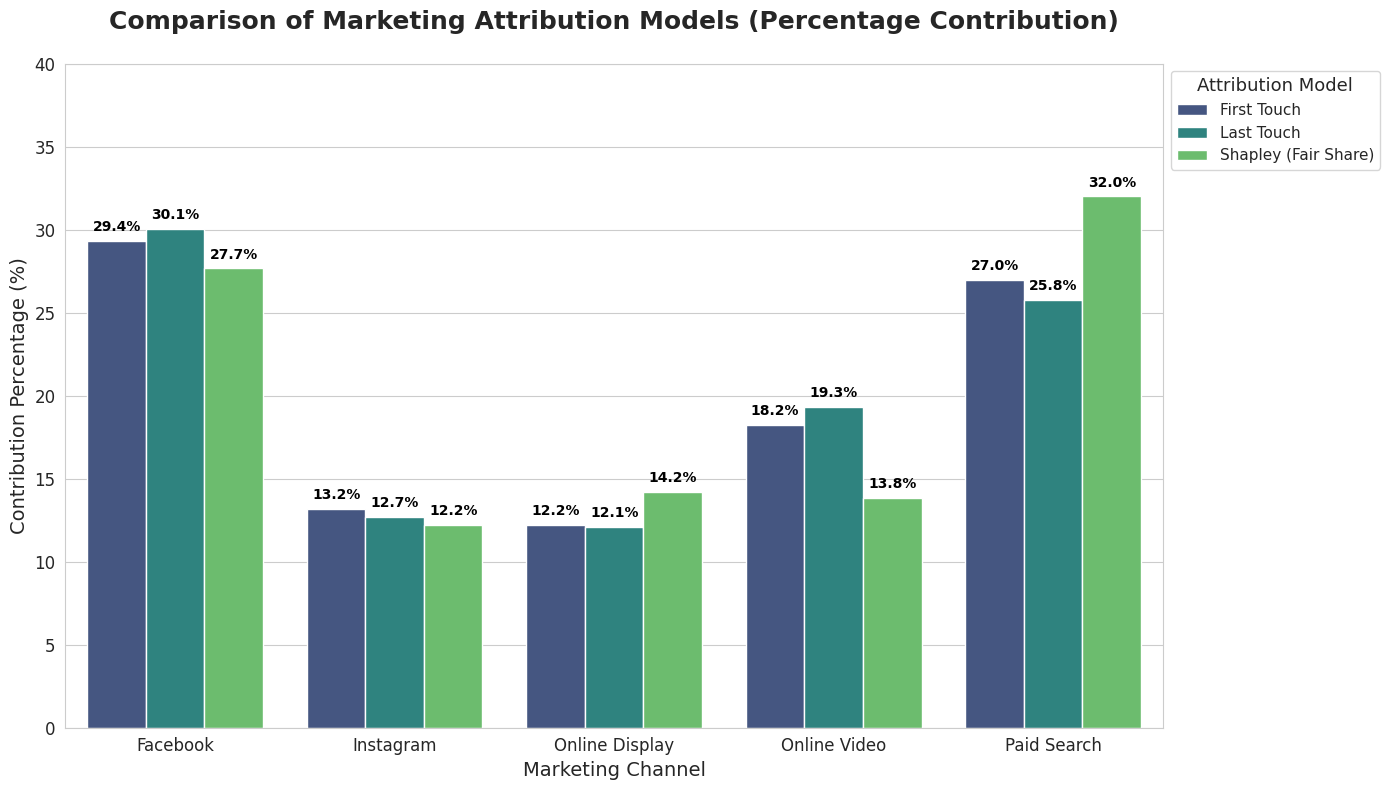

In [30]:
df_melted = result_percentage.melt(id_vars="channel",
                                    var_name="attribution_model",
                                    value_name="percentage")
df_melted['attribution_model'] = df_melted['attribution_model'].replace({
    'first_touch_conversions in percentage': 'First Touch',
    'last_touch_conversions in percentage': 'Last Touch',
    'shapley_value in percentage': 'Shapley (Fair Share)'
})
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
ax = sns.barplot(x="channel", y="percentage", hue="attribution_model",
                 data=df_melted, palette="viridis")
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 10),
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='black')

plt.title('Comparison of Marketing Attribution Models (Percentage Contribution)',
          fontsize=18, fontweight='bold', pad=25)
plt.ylabel('Contribution Percentage (%)', fontsize=14)
plt.xlabel('Marketing Channel', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Attribution Model', title_fontsize='13', fontsize='11',
           loc='upper left', bbox_to_anchor=(1, 1))
plt.ylim(0, max(df_melted['percentage']) + 8)

plt.tight_layout()
plt.savefig('attribution_comparison.png')
plt.show()